In [8]:
import pandas as pd
import numpy as np
import pyreadr
import matplotlib.pyplot as plt
import lmfit
from lmfit import Parameters

In [9]:
result = pyreadr.read_r("../../../data/swiss/raw/SM_SWP_daily_binned_2perc.rds") # also works for RData
df_all = result[None]

In [10]:
df = df_all[['pos','SM_daily', 'SWP_daily', 'SM_mean','SWP_mean']]
df_mid = df[df['pos'] == 'mid']
df_mid.to_csv("../../../data/swiss/raw/swp_vwc_mid.cvs")
df_top = df[df['pos'] == 'top']
df_top.to_csv("../../../data/swiss/raw/swp_vwc_top.cvs")

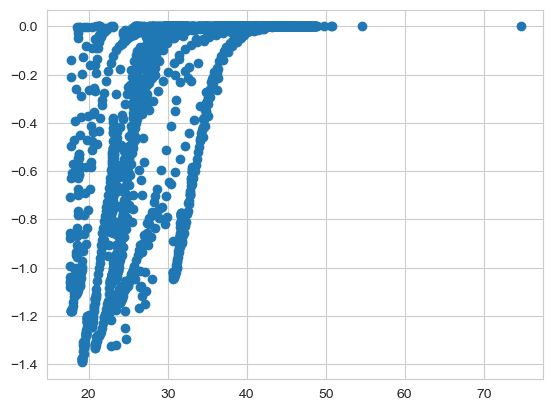

In [11]:
plt.scatter(df_mid['SM_daily'], df_mid['SWP_daily'])

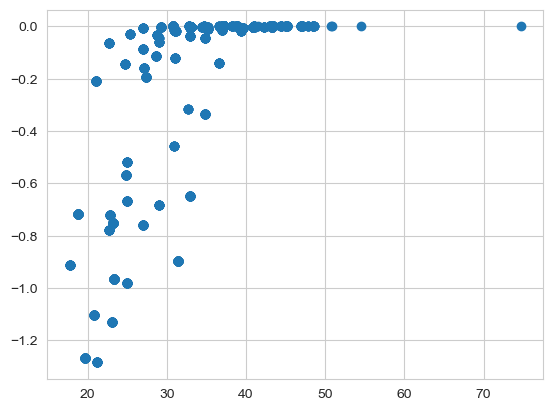

In [12]:
plt.scatter(df_mid['SM_mean'], df_mid['SWP_mean'])

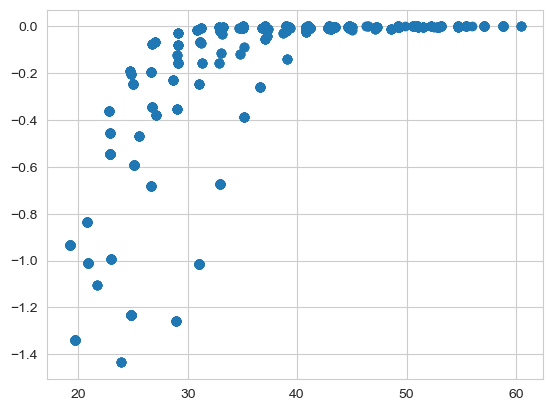

In [13]:
plt.scatter(df_top['SM_mean'], df_top['SWP_mean'])

In [14]:
theta_s_pre = 54
def base(theta, theta_r, theta_s):
    return (theta - theta_r) / (theta_s - theta_r)
def psi_org(theta, theta_r, theta_s, psi_a, m, n):
    return psi_a*(base(theta,theta_r,theta_s) ** (-1.0/m) - 1)**(1.0/n)
def psi_org_c(theta, psi_a, m, n):
    return psi_org(theta, 0, theta_s_pre, psi_a, m, n)
def psi_red_c(theta, psi_a, p):
    n = p + 1;
    m = p/n;
    return psi_a*(base(theta, 0, theta_s_pre) ** (-1.0/m) - 1)**(1.0/n)

def k_soil_red_c(theta, k_sat, p):
    theta_r = 0.15
    theta_s = theta_s_pre
    n = p + 1
    m = p/n
    
    return((k_sat *np.sqrt(abs(base(theta, theta_r, theta_s))) * 
     (1.0-(1.0 - base(theta, theta_r, theta_s)**(1.0/m))**m)**2))

In [15]:
psi_org_c(10, -0.022, 0.3, 0.9)

-11.304262881484082

In [16]:
model = lmfit.Model(psi_red_c)
params = Parameters()
params.add("psi_a", value = -0.015, min = -0.1, max = 0)
params.add("p", value = 0.2, min = 0, max = 1.5)

In [17]:
df_s = df[df['pos'] == 'mid']
input_df = df_s[['SM_mean','SWP_mean']]
input_df.drop_duplicates(inplace=True);
input_df = input_df[input_df['SM_mean'] < theta_s_pre]
result = model.fit(input_df['SWP_mean'], params, theta=input_df['SM_mean'], method='leastsq')
print(result.fit_report())

[[Model]]
    Model(psi_red_c)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 25
    # data points      = 83
    # variables        = 2
    chi-square         = 4.83205608
    reduced chi-square = 0.05965501
    Akaike info crit   = -232.016189
    Bayesian info crit = -227.178508
    R-squared          = 0.54610522
[[Variables]]
    psi_a: -0.03497552 +/- 0.01480133 (42.32%) (init = -0.015)
    p:      0.30837340 +/- 0.04334104 (14.05%) (init = 0.2)
[[Correlations]] (unreported correlations are < 0.100)
    C(psi_a, p) = -0.9828


/var/folders/9r/97b9zk_j4ys8v5lnksc4l4j00000gq/T/ipykernel_46182/1271752803.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  input_df.drop_duplicates(inplace=True);


In [18]:
fit_psi_a = result.values['psi_a']
fit_p= result.values['p']

In [19]:
x = np.arange(18, 60, 0.1)

In [20]:
result

In [21]:
ci = result.conf_interval(sigmas=[0.5,1])
lmfit.printfuncs.report_ci(ci)
psi_a_lower = ci['psi_a'][0][1]
psi_a_upper = ci['psi_a'][4][1]

p_lower = ci['p'][0][1]
p_upper = ci['p'][4][1]

          68.27%    50.00%    _BEST_    50.00%    68.27%
 psi_a:  -0.01530  -0.00981  -0.03498  +0.00802  +0.01135
 p    :  -0.03488  -0.02419   0.30837  +0.02777  +0.04282


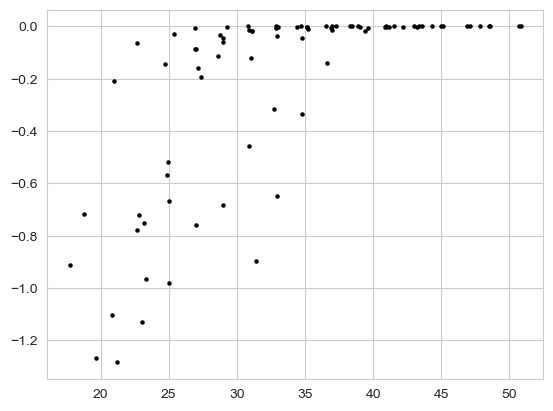

In [25]:
plt.scatter(input_df['SM_mean'], input_df['SWP_mean'], color = 'black',  s= 5, alpha = 1.0)


In [7]:

plt.scatter(input_df['SM_mean'], input_df['SWP_mean'], color = 'black',  s= 5, alpha = 0.6)
plt.plot(x, psi_red_c(x, fit_psi_a, fit_p), color = 'tab:red')
plt.plot(x, psi_red_c(x, psi_a_lower, p_lower), color = 'tab:blue')
plt.plot(x, psi_red_c(x, psi_a_upper, p_upper), color = 'tab:blue')
plt.fill_between(x, psi_red_c(x, psi_a_lower, p_lower), psi_red_c(x, psi_a_upper, p_upper), alpha=0.2)
plt.ylim((-2, 0.05));

NameError: name 'input_df' is not defined

/var/folders/9r/97b9zk_j4ys8v5lnksc4l4j00000gq/T/ipykernel_46182/239264573.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  input_df.drop_duplicates(inplace=True);


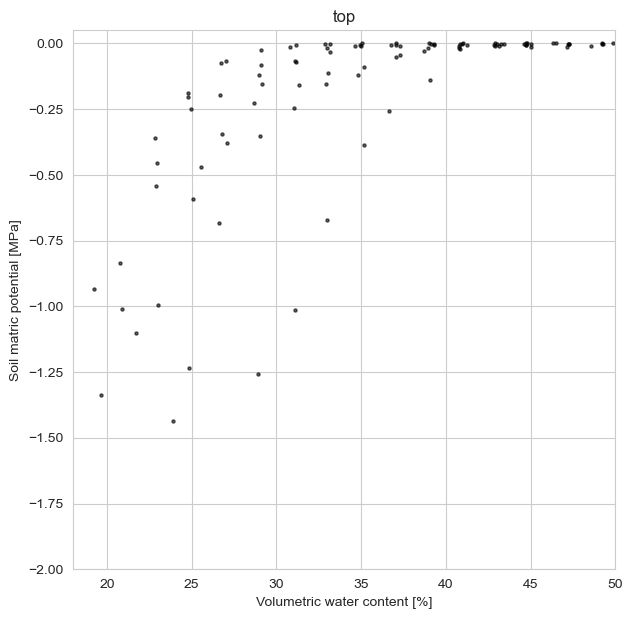

In [39]:
fig = plt.figure(figsize=(7,7))

psi_a_list= []
p_list= []

for layer_str, plt_index in zip(['top'], range(1,3)):

    ax = fig.add_subplot(1,1,plt_index)
    df_s = df[df['pos'] == layer_str]
    input_df = df_s[['SM_mean', 'SWP_mean']]
    input_df.drop_duplicates(inplace=True);
    input_df = input_df[input_df['SM_mean'] < theta_s_pre]
    result = model.fit(input_df['SWP_mean'], params, theta=input_df['SM_mean'], method='leastsq')
    #print(result.fit_report())
    
    fit_psi_a = result.values['psi_a']
    fit_p= result.values['p']
    
    psi_a_list.append(fit_psi_a)
    p_list.append(fit_p)
    
    ci = result.conf_interval(sigmas=[1, 2])
    
    n = fit_p + 1;
    m = fit_p/n;
    
    psi_a_lower = ci['psi_a'][0][1]
    psi_a_upper = ci['psi_a'][4][1]
    
    p_lower = ci['p'][0][1]
    p_upper = ci['p'][4][1]
    
    
    ax.scatter(input_df['SM_mean'], input_df['SWP_mean'], color = 'black',  s= 5, alpha = 0.6)
    #ax.plot(x, psi_red_c(x, fit_psi_a, fit_p), color = 'tab:red')
    #ax.plot(x, psi_red_c(x, psi_a_lower, p_lower), color = 'tab:blue')
    #ax.plot(x, psi_red_c(x, psi_a_upper, p_upper), color = 'tab:blue')
    #ax.fill_between(x, psi_red_c(x, psi_a_lower, p_lower), psi_red_c(x, psi_a_upper, p_upper), alpha=0.2)
    ax.set_ylim((-2, 0.05));
    ax.set_xlim((18, 50));
    #ax.text(0.3, 0.2, f"$\psi_a  = {np.round(fit_psi_a, 3)}$ $CI_\sigma$: ({np.round(psi_a_lower,3)}, {np.round(psi_a_upper, 3)}) MPa",
     #       transform = ax.transAxes, horizontalalignment ='left', fontsize = 14);
    #ax.text(0.3, 0.12, r"$\alpha_\mathrm{soil}=" +f"{np.round(fit_p, 3)}$ $CI_\sigma$: ({np.round(p_lower,3)}, {np.round(p_upper, 3)})",
      #      transform = ax.transAxes, horizontalalignment ='left', fontsize = 14);
    # ax.text(0.4, 0.10, f"$m  = {np.round(m, 3)}$",
    #                 transform = ax.transAxes, horizontalalignment ='left');
    # ax.text(0.4, 0.05, f"$n  = {np.round(n, 3)}$",
    #         transform = ax.transAxes, horizontalalignment ='left');
    ax.set_title(layer_str)
    ax.set_xlabel(f"Volumetric water content [%]" )
    ax.set_ylabel(f"Soil matric potential [MPa]" )
plt.savefig("I0.png", dpi = 300)

<>:41: SyntaxWarning: invalid escape sequence '\p'
<>:41: SyntaxWarning: invalid escape sequence '\s'
<>:43: SyntaxWarning: invalid escape sequence '\s'
<>:41: SyntaxWarning: invalid escape sequence '\p'
<>:41: SyntaxWarning: invalid escape sequence '\s'
<>:43: SyntaxWarning: invalid escape sequence '\s'
/var/folders/9r/97b9zk_j4ys8v5lnksc4l4j00000gq/T/ipykernel_46182/174454585.py:41: SyntaxWarning: invalid escape sequence '\p'
  ax.text(0.3, 0.2, f"$\psi_a  = {np.round(fit_psi_a, 3)}$ $CI_\sigma$: ({np.round(psi_a_lower,3)}, {np.round(psi_a_upper, 3)}) MPa",
/var/folders/9r/97b9zk_j4ys8v5lnksc4l4j00000gq/T/ipykernel_46182/174454585.py:41: SyntaxWarning: invalid escape sequence '\s'
  ax.text(0.3, 0.2, f"$\psi_a  = {np.round(fit_psi_a, 3)}$ $CI_\sigma$: ({np.round(psi_a_lower,3)}, {np.round(psi_a_upper, 3)}) MPa",
/var/folders/9r/97b9zk_j4ys8v5lnksc4l4j00000gq/T/ipykernel_46182/174454585.py:43: SyntaxWarning: invalid escape sequence '\s'
  ax.text(0.3, 0.14, r"$\alpha_\mathrm{soil}=" +

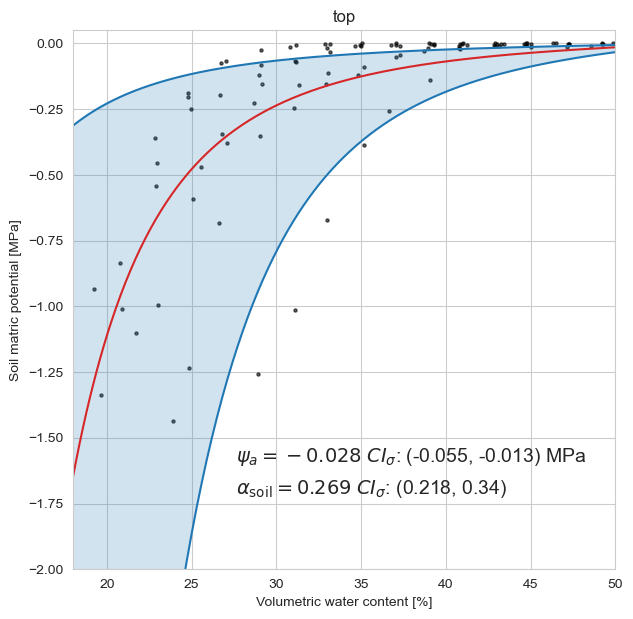

In [41]:
fig = plt.figure(figsize=(7,7))

psi_a_list= []
p_list= []

for layer_str, plt_index in zip(['top'], range(1,3)):

    ax = fig.add_subplot(1,1,plt_index)
    df_s = df[df['pos'] == layer_str]
    input_df = df_s[['SM_mean', 'SWP_mean']]
    input_df.drop_duplicates(inplace=True);
    input_df = input_df[input_df['SM_mean'] < theta_s_pre]
    result = model.fit(input_df['SWP_mean'], params, theta=input_df['SM_mean'], method='leastsq')
    #print(result.fit_report())
    
    fit_psi_a = result.values['psi_a']
    fit_p= result.values['p']
    
    psi_a_list.append(fit_psi_a)
    p_list.append(fit_p)
    
    ci = result.conf_interval(sigmas=[1, 2])
    
    n = fit_p + 1;
    m = fit_p/n;
    
    psi_a_lower = ci['psi_a'][0][1]
    psi_a_upper = ci['psi_a'][4][1]
    
    p_lower = ci['p'][0][1]
    p_upper = ci['p'][4][1]
    
    
    ax.scatter(input_df['SM_mean'], input_df['SWP_mean'], color = 'black',  s= 5, alpha = 0.6)
    ax.plot(x, psi_red_c(x, fit_psi_a, fit_p), color = 'tab:red')
    ax.plot(x, psi_red_c(x, psi_a_lower, p_lower), color = 'tab:blue')
    ax.plot(x, psi_red_c(x, psi_a_upper, p_upper), color = 'tab:blue')
    ax.fill_between(x, psi_red_c(x, psi_a_lower, p_lower), psi_red_c(x, psi_a_upper, p_upper), alpha=0.2)
    ax.set_ylim((-2, 0.05));
    ax.set_xlim((18, 50));
    ax.text(0.3, 0.2, f"$\psi_a  = {np.round(fit_psi_a, 3)}$ $CI_\sigma$: ({np.round(psi_a_lower,3)}, {np.round(psi_a_upper, 3)}) MPa",
            transform = ax.transAxes, horizontalalignment ='left', fontsize = 14);
    ax.text(0.3, 0.14, r"$\alpha_\mathrm{soil}=" +f"{np.round(fit_p, 3)}$ $CI_\sigma$: ({np.round(p_lower,3)}, {np.round(p_upper, 3)})",
            transform = ax.transAxes, horizontalalignment ='left', fontsize = 14);
    # ax.text(0.4, 0.10, f"$m  = {np.round(m, 3)}$",
    #                 transform = ax.transAxes, horizontalalignment ='left');
    # ax.text(0.4, 0.05, f"$n  = {np.round(n, 3)}$",
    #         transform = ax.transAxes, horizontalalignment ='left');
    ax.set_title(layer_str)
    ax.set_xlabel(f"Volumetric water content [%]" )
    ax.set_ylabel(f"Soil matric potential [MPa]" )
plt.savefig("I1.png", dpi = 300)


In [43]:
df_new_soils =pd.read_csv("../../../data/swiss/input/Water_content_MultiSoils.csv")

In [44]:
df_new_soils['dates'] = pd.to_datetime(df_new_soils['dates'])
df_new_soils.set_index('dates', inplace=True)

In [45]:
i = 0
df_combine = pd.DataFrame(df_new_soils.index)
df_combine.set_index('dates', inplace=True)
for i, s in zip(range(3), ['10', '40', '80']):
    sel = np.arange(0 + i, 24 + i, 3)
    df_combine[f'theta_{s}cm'] = df_new_soils.iloc[:, sel].values.mean(axis= 1)
    df_combine[f'theta_std_{s}cm'] = df_new_soils.iloc[:, sel].values.std(axis= 1)

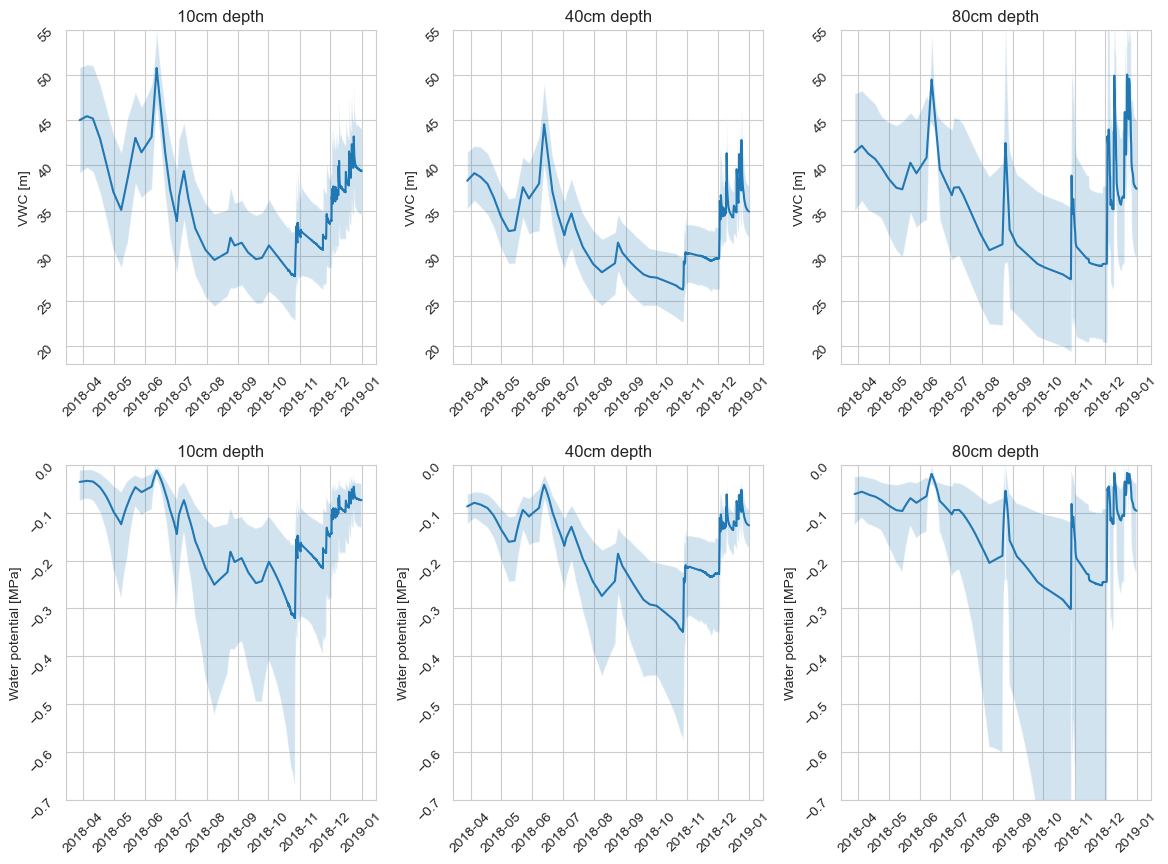

In [46]:
fig = plt.figure(figsize=(14,10))
for id, s in zip(range(1, 4), ['10', '40', '80']):
    ax = fig.add_subplot(2,3,id)
    ax.plot(df_combine[f'theta_{s}cm'])
    ax.fill_between(df_combine.index , df_combine[f'theta_{s}cm']- df_combine[f'theta_std_{s}cm'], df_combine[f'theta_{s}cm'] + df_combine[f'theta_std_{s}cm'], alpha = 0.2)
    ax.set_ylim(18, 55)
    ax.tick_params(labelrotation=45)
    ax.set_title(f"{s}cm depth")
    ax.set_ylabel("VWC [m]")
    
for id, s, di in zip(range(4, 7), ['10', '40', '80'], [0,1,1]):
    ax = fig.add_subplot(2,3,id)    
    df_psi = psi_red_c(df_combine[f'theta_{s}cm'], psi_a_list[di], p_list[di]).to_frame()
    df_psi_std_low = psi_red_c(df_combine[f'theta_{s}cm']-df_combine[f'theta_std_{s}cm'], psi_a_list[di], p_list[di]).to_frame()
    df_psi_std_up = psi_red_c(df_combine[f'theta_{s}cm']+df_combine[f'theta_std_{s}cm'], psi_a_list[di], p_list[di]).to_frame()
    ax.plot(df_psi[f'theta_{s}cm'])
    ax.fill_between(df_psi.index ,df_psi_std_low[0], df_psi_std_up[0], alpha = 0.2)
    ax.set_ylim(-0.7, 0)
    ax.set_ylabel("Water potential [MPa]")
    ax.set_title(f"{s}cm depth")
    ax.tick_params(labelrotation=45)
plt.subplots_adjust(hspace = 0.3, wspace=0.25)
plt.savefig("Timeseries of water content and water potential.png", dpi = 300)

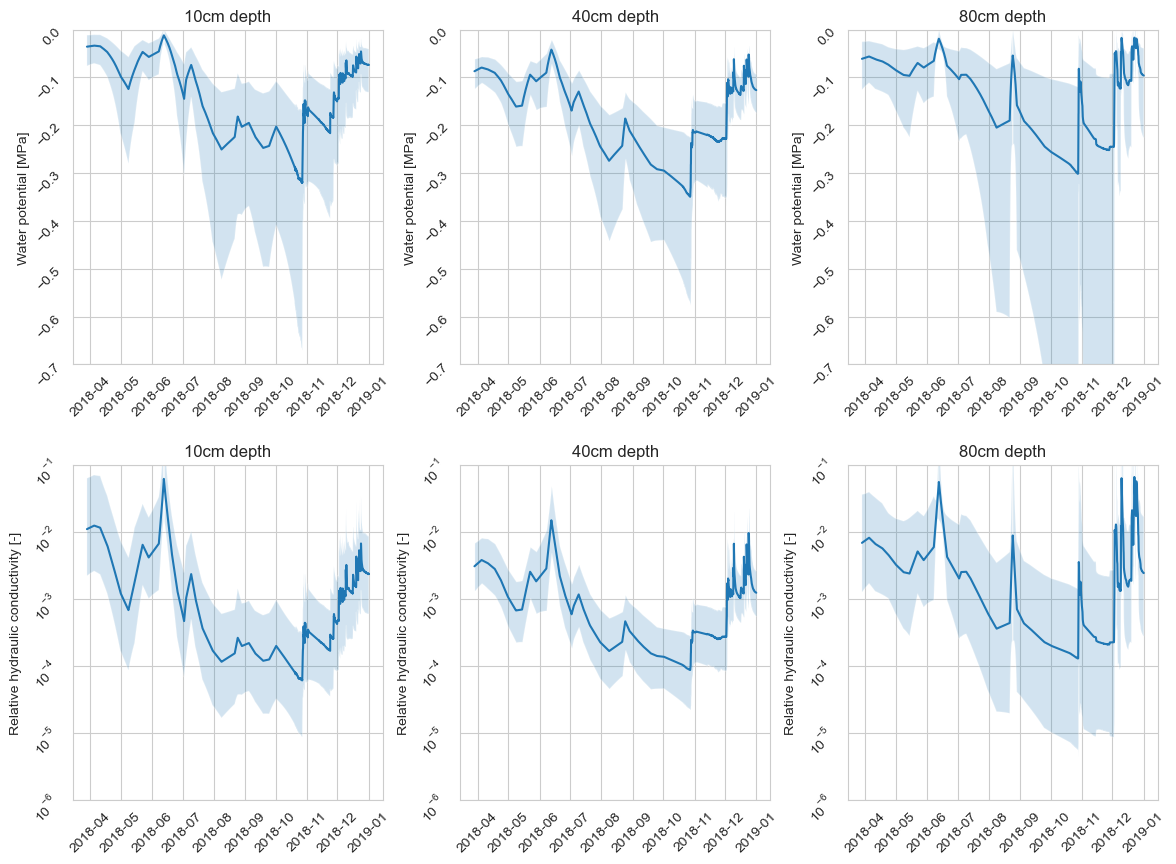

In [47]:
fig = plt.figure(figsize=(14, 10))
for id, s, di in zip(range(1, 4), ['10', '40', '80'], [0, 1, 1]):
    ax = fig.add_subplot(2, 3, id)
    df_psi = psi_red_c(df_combine[f'theta_{s}cm'], psi_a_list[di], p_list[di]).to_frame()
    df_psi_std_low = psi_red_c(df_combine[f'theta_{s}cm'] - df_combine[f'theta_std_{s}cm'], psi_a_list[di],
                               p_list[di]).to_frame()
    df_psi_std_up = psi_red_c(df_combine[f'theta_{s}cm'] + df_combine[f'theta_std_{s}cm'], psi_a_list[di],
                              p_list[di]).to_frame()
    ax.plot(df_psi[f'theta_{s}cm'])
    ax.fill_between(df_psi.index, df_psi_std_low[0], df_psi_std_up[0], alpha=0.2)
    ax.set_ylim(-0.7, 0)
    ax.set_ylabel("Water potential [MPa]")
    ax.set_title(f"{s}cm depth")
    ax.tick_params(labelrotation=45)

for id, s, di in zip(range(4, 7), ['10', '40', '80'], [0, 1, 1]):
    ax = fig.add_subplot(2, 3, id)
    df_k = k_soil_red_c(df_combine[f'theta_{s}cm'], 1.0, p_list[di]).to_frame()
    df_k_low = k_soil_red_c(df_combine[f'theta_{s}cm'] - df_combine[f'theta_std_{s}cm'], 1.0, p_list[di]).to_frame()
    df_k_up = k_soil_red_c(df_combine[f'theta_{s}cm'] + df_combine[f'theta_std_{s}cm'], 1.0, p_list[di]).to_frame()
    ax.plot(df_k[f'theta_{s}cm'])
    ax.fill_between(df_k.index, df_k_low[0], df_k_up[0], alpha=0.2)
    ax.set_ylabel("Relative hydraulic conductivity [-]")
    ax.set_title(f"{s}cm depth")
    ax.tick_params(labelrotation=45)
    ax.set_yscale('log')
    ax.set_ylim((1E-6,1E-1))


plt.subplots_adjust(hspace = 0.3, wspace=0.25)
plt.savefig("Timeseries of hydraulic conductivity and water potential.png", dpi = 300)

In [27]:
df_combine_sel = df_combine.iloc[(df_combine.index > "2018-04-28 01:30:00")&(df_combine.index < "2018-12-31 14:30:00")]
df_combine_sel *= 1.0/100.0
df_combine_sel.to_csv("vwc_swicc_cc_2023_std_n.csv")
df_combine_sel

,theta_10cm,theta_std_10cm,theta_40cm,theta_std_40cm,theta_80cm,theta_std_80cm
dates,,,,,,
2018-04-28 02:00:00,0.382426,0.063289,0.351365,0.034256,0.390305,0.059873
2018-04-28 02:30:00,0.382329,0.063300,0.351302,0.034262,0.390267,0.059891
2018-04-28 03:00:00,0.382233,0.063310,0.351238,0.034267,0.390229,0.059909
2018-04-28 03:30:00,0.382137,0.063321,0.351175,0.034273,0.390192,0.059927
2018-04-28 04:00:00,0.382040,0.063331,0.351111,0.034279,0.390154,0.059945
...,...,...,...,...,...,...
2018-12-31 12:00:00,0.393736,0.047140,0.349341,0.028123,0.374628,0.076116
2018-12-31 12:30:00,0.393761,0.047163,0.349341,0.028123,0.374614,0.076091
2018-12-31 13:00:00,0.393785,0.047186,0.349341,0.028123,0.374601,0.076066


In [28]:
df_new_soils_sel = df_new_soils.iloc[(df_new_soils.index > "2018-04-28 01:30:00")&(df_new_soils.index < "2018-12-31 14:30:00")]
df_new_soils_sel *= 1.0/100.0
df_new_soils_sel.to_csv("vwc_swicc_cc_2023_indiv.csv")
df_new_soils_sel

,Pit01_10,Pit01_40,Pit01_80,Pit02_10,Pit02_40,Pit02_80,Pit03_10,Pit03_40,Pit03_80,Pit04_10,...,Pit05_80,Pit06_10,Pit06_40,Pit06_80,Pit07_10,Pit07_40,Pit07_80,Pit08_10,Pit08_40,Pit08_80
dates,,,,,,,,,,,,,,,,,,,,,
2018-04-28 02:00:00,0.329566,0.275719,0.282598,0.313268,0.336323,0.390423,0.395231,0.344875,0.437730,0.373695,...,0.362263,0.507302,0.393319,0.451440,0.381675,0.357708,0.478697,0.444958,0.388288,0.377123
2018-04-28 02:30:00,0.329463,0.275647,0.282542,0.313175,0.336255,0.390399,0.395174,0.344840,0.437720,0.373587,...,0.362252,0.507185,0.393282,0.451439,0.381613,0.357630,0.478683,0.444898,0.388237,0.376985
2018-04-28 03:00:00,0.329361,0.275575,0.282486,0.313083,0.336188,0.390375,0.395117,0.344806,0.437710,0.373480,...,0.362241,0.507067,0.393246,0.451438,0.381550,0.357553,0.478668,0.444837,0.388187,0.376846
2018-04-28 03:30:00,0.329259,0.275503,0.282430,0.312991,0.336121,0.390350,0.395060,0.344772,0.437700,0.373372,...,0.362229,0.506949,0.393209,0.451437,0.381487,0.357476,0.478654,0.444777,0.388136,0.376707
2018-04-28 04:00:00,0.329156,0.275431,0.282374,0.312899,0.336053,0.390326,0.395003,0.344738,0.437690,0.373265,...,0.362218,0.506832,0.393173,0.451436,0.381425,0.357398,0.478640,0.444717,0.388086,0.376569
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-12-31 12:00:00,0.322497,0.306167,0.233833,0.394019,0.318383,0.353761,0.400680,0.333653,0.383621,0.403098,...,0.337890,0.499490,0.394557,0.406297,0.394112,0.369350,0.515744,0.373351,0.375825,0.425394
2018-12-31 12:30:00,0.322328,0.306167,0.233833,0.394212,0.318383,0.353761,0.400680,0.333653,0.383621,0.403098,...,0.337890,0.499490,0.394557,0.406297,0.394112,0.369350,0.515636,0.373524,0.375825,0.425394
2018-12-31 13:00:00,0.322160,0.306167,0.233833,0.394404,0.318383,0.353761,0.400680,0.333653,0.383621,0.403098,...,0.337890,0.499490,0.394557,0.406297,0.394112,0.369350,0.515528,0.373696,0.375825,0.425394


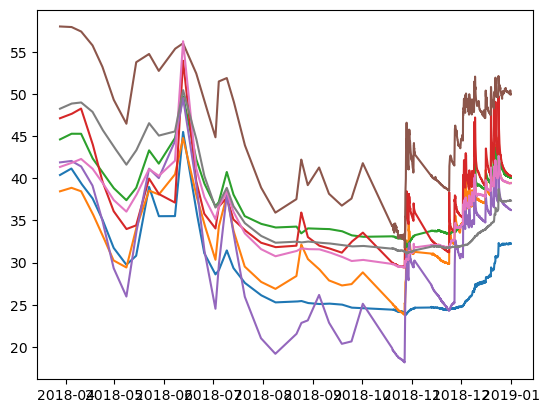

In [32]:
i = 0
for s in np.arange(0 + i, 24 + i, 3):
    plt.plot(df_new_soils.iloc[:,s])


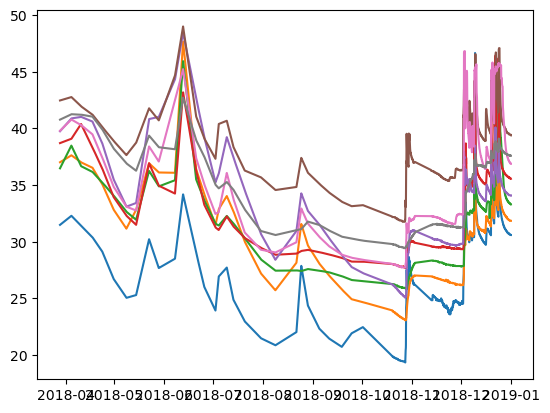

In [34]:
i = 1

for s in np.arange(0 + i, 24 + i, 3):
    plt.plot(df_new_soils.iloc[:,s])

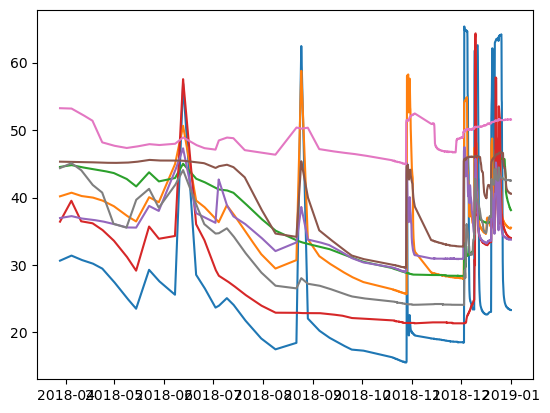

In [23]:
i = 2

for s in np.arange(0 + i, 24 + i, 3):
    plt.plot(df_new_soils.iloc[:,s])